In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
# Import data here
df=pd.read_csv("../datasets/Labeled/train_dataset.csv", header=None)
df_test=pd.read_csv("../datasets/Labeled/test_dataset.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,Socket,Execution Time,Power,Current,Voltage,Memory,CPU Usage,Read Bytes,Write Bytes,Signature,...,Size,Avg File Size,CPU Count,Total RAM,Available RAM,System CPU,System Memory,Time Per File,Throughput,Algorithm
1,rpi3,109.77205580699956,3.909131578947368,0.04947368421052632,116.67165789473684,320.1236324310303,99.99812720370008,325058953,0,207030,...,310.0,62.0,4,923.20703125,730.96875,0.5,20.8,21.94864715499989,2.8247754662125697,cross-rsdp-192-fast
2,rpi4,6.252172244999997,3.726,0.048,116.178,320.122727394104,99.96525615554296,325059001,0,207030,...,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.2,1.248899219399982,49.64371747288554,cross-rsdp-192-fast
3,rpi4,5.413318097000001,3.77,0.048,115.747,320.0559024810791,99.75397534818109,325059001,0,92160,...,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.1,1.0811231009999802,57.347770982465704,cross-rsdp-128-fast
4,rpi4,6.159591703000046,3.7439999999999998,0.043,116.004,320.02650260925293,100.00662863741042,325058998,0,23135,...,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.2,1.2303292149999607,50.393016148935374,ML-DSA-87


In [3]:
df.columns = df.iloc[0]
df_test.columns = df_test.iloc[0]
df = df[1:]
df_test = df_test[1:]
df.head()

,Socket,Execution Time,Power,Current,Voltage,Memory,CPU Usage,Read Bytes,Write Bytes,Signature,...,Size,Avg File Size,CPU Count,Total RAM,Available RAM,System CPU,System Memory,Time Per File,Throughput,Algorithm
1,rpi3,109.77205580699956,3.909131578947368,0.04947368421052632,116.67165789473684,320.1236324310303,99.99812720370008,325058953,0,207030,...,310.0,62.0,4,923.20703125,730.96875,0.5,20.8,21.94864715499989,2.8247754662125697,cross-rsdp-192-fast
2,rpi4,6.252172244999997,3.726,0.048,116.178,320.122727394104,99.96525615554296,325059001,0,207030,...,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.2,1.248899219399982,49.64371747288554,cross-rsdp-192-fast
3,rpi4,5.413318097000001,3.77,0.048,115.747,320.0559024810791,99.75397534818109,325059001,0,92160,...,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.1,1.0811231009999802,57.347770982465704,cross-rsdp-128-fast
4,rpi4,6.159591703000046,3.7439999999999998,0.043,116.004,320.02650260925293,100.00662863741042,325058998,0,23135,...,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.2,1.2303292149999607,50.393016148935374,ML-DSA-87
5,rpi3,46.0946591930001,3.946533333333333,0.05013333333333335,116.19699999999999,320.10715198516846,99.96819763231404,325058952,0,178320,...,310.0,62.0,4,923.20703125,730.96875,0.0,20.7,9.2097393948,6.7320037345471935,SLH_DSA_PURE_SHA2_192F


In [4]:
# Feature selection
X_train = df.drop(['Algorithm'], axis=1)
y_train = df['Algorithm']
X_test = df_test.drop(['Algorithm'], axis=1)
y_test = df_test['Algorithm']

# Ensure consistent data types
string_cols_train = X_train.columns[X_train.columns != 'Socket']
X_train[string_cols_train] = X_train[string_cols_train].astype(float)
string_cols_test = X_test.columns[X_test.columns != 'Socket']
X_test[string_cols_test] = X_test[string_cols_test].astype(float)

# Align test features with training features
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [5]:
# Split data
import numpy as np

object_cols = [col for col in X_train.columns if X_train[col].dtype == "object"]
low_cardinality_cols = [col for col in object_cols if X_train[col].nunique() < 10]
high_cardinality_cols = list(set(object_cols)-set(low_cardinality_cols))

categories = X_train.select_dtypes(exclude=np.number).columns.tolist()
for col in categories:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

X_train.dropna()

,Socket,Execution Time,Power,Current,Voltage,Memory,CPU Usage,Read Bytes,Write Bytes,Signature,Num Files,Size,Avg File Size,CPU Count,Total RAM,Available RAM,System CPU,System Memory,Time Per File,Throughput
1,rpi3,109.772056,3.909132,0.049474,116.671658,320.123632,99.998127,325058953.0,0.0,207030.0,5.0,310.0,62.0,4.0,923.207031,730.968750,0.5,20.8,21.948647,2.824775
2,rpi4,6.252172,3.726000,0.048000,116.178000,320.122727,99.965256,325059001.0,0.0,207030.0,5.0,310.0,62.0,4.0,7812.316406,7118.945312,0.0,9.2,1.248899,49.643717
3,rpi4,5.413318,3.770000,0.048000,115.747000,320.055902,99.753975,325059001.0,0.0,92160.0,5.0,310.0,62.0,4.0,7812.316406,7118.945312,0.0,9.1,1.081123,57.347771
4,rpi4,6.159592,3.744000,0.043000,116.004000,320.026503,100.006629,325058998.0,0.0,23135.0,5.0,310.0,62.0,4.0,7812.316406,7118.945312,0.0,9.2,1.230329,50.393016
5,rpi3,46.094659,3.946533,0.050133,116.197000,320.107152,99.968198,325058952.0,0.0,178320.0,5.0,310.0,62.0,4.0,923.207031,730.968750,0.0,20.7,9.209739,6.732004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,rpi3,17.988799,4.192143,0.052429,116.370429,320.053449,99.951088,325058952.0,0.0,85440.0,5.0,310.0,62.0,4.0,923.207031,730.968750,0.2,20.7,3.585079,17.293902
129,rpi3,17.988799,4.192143,0.052429,116.370429,320.053449,99.951088,325058952.0,0.0,85440.0,5.0,310.0,62.0,4.0,923.207031,730.968750,0.2,20.7,3.585079,17.293902
130,rpi3,114.451311,3.914410,0.049103,116.871077,327.802616,99.998854,325058954.0,0.0,1300.0,5.0,310.0,62.0,4.0,923.207031,730.968750,0.0,20.9,21.890817,2.832238
131,rpi5,2.599969,4.418000,0.057000,116.319000,320.021165,100.385805,325059017.0,0.0,16545.0,5.0,310.0,62.0,4.0,16215.125000,15631.937500,0.0,5.5,0.519584,119.326237


In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [7]:
# Create regression matrices
dtrain_reg = xgb.DMatrix(X_train, y_train_encoded, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test_encoded, enable_categorical=True)

xgb_model = xgb.train(
    params={
        'objective': 'multi:softmax',
        'num_class': len(label_encoder.classes_),
        'eval_metric': 'mlogloss'
    },
    dtrain=dtrain_reg,
    num_boost_round=100
)

In [8]:
y_predict = xgb_model.predict(dtest_reg)

In [9]:
# Accuracy
import numpy as np

print("Accuracy of XGBoost model is ", metrics.accuracy_score(y_test_encoded, y_predict))
print("Precision (weighted) is ", metrics.precision_score(y_test_encoded, y_predict, average="weighted", zero_division=np.NaN))
print("Recall (weighted) is ", metrics.recall_score(y_test_encoded, y_predict, average="weighted", zero_division=np.NaN))
print("F1 Score (weighted) is ", metrics.f1_score(y_test_encoded, y_predict, average="weighted"))

Accuracy of XGBoost model is  0.9545454545454546
Precision (weighted) is  0.9696969696969697
Recall (weighted) is  0.9545454545454546
F1 Score (weighted) is  0.9515151515151515


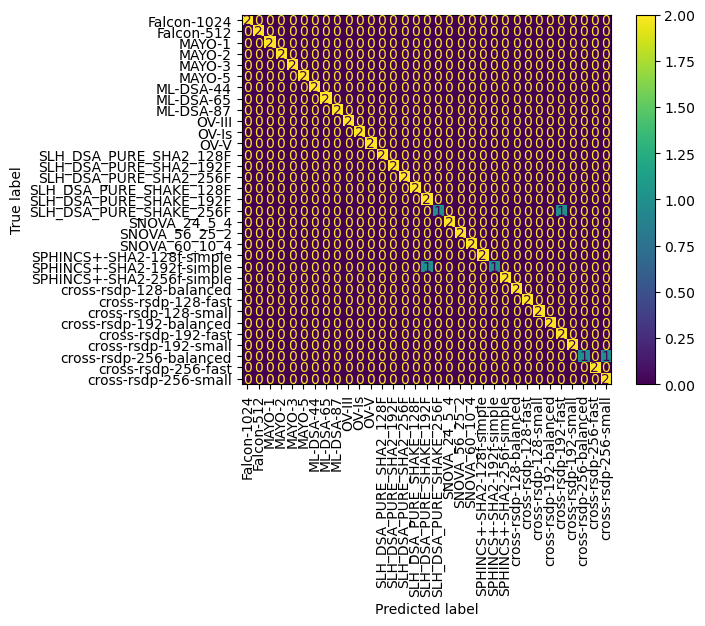

In [10]:
# Confusion matrix
# labels = ["cipher1", "cipher2", ...]
cm = metrics.confusion_matrix(y_test_encoded, y_predict)
display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
display.plot(xticks_rotation='vertical')

In [11]:
# ROC curve
from sklearn.preprocessing import label_binarize

y_scores = xgb_model.predict(dtest_reg, output_margin=True)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = metrics.roc_curve(y_test_bin[:, i], y_scores[:, 1])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])

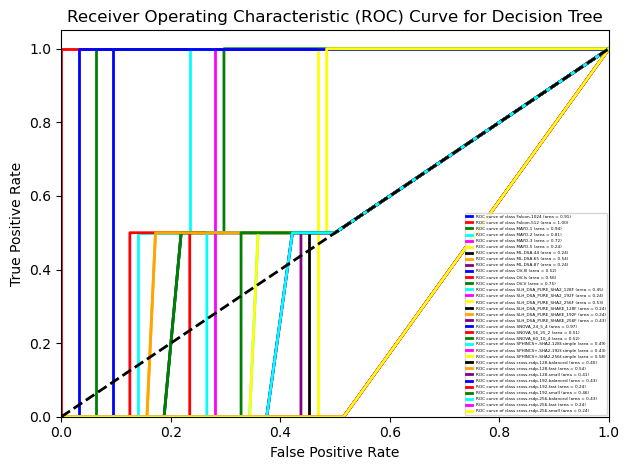

In [12]:
# Plot the ROC curve for each class
import matplotlib.pyplot as plt
from itertools import cycle

plt.figure()
classes = label_encoder.classes_
colors = ['blue', 'red', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple']
color_cycle = cycle(colors)
for i, cur_class in zip(range(n_classes), classes):
    color = next(color_cycle)
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(cur_class, roc_auc[i]))

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve for Decision Tree")
plt.legend(
    fontsize='3',
    markerscale=0.7,
    handlelength=1.5,
    labelspacing=0.5,
    borderpad=0.3,
    loc="lower right"
)
plt.tight_layout()
plt.show()

In [13]:
from joblib import dump

dump(xgb_model, 'xgboost.joblib')

['xgboost.joblib']